<a href="https://colab.research.google.com/github/ashwiniv07/Journal-paper--DDoS-GT-DL-/blob/main/Dataset4_CIC_IDS2017_without_resampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [ ]:
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Bidirectional, GRU, Dense,
    Dropout, Flatten, Attention, Permute, Multiply, Lambda, GlobalAveragePooling1D
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import shutil
from pathlib import Path
from scipy import stats
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1: Dataset Collection

In [ ]:
path = '/content/drive/MyDrive/project ashwini/CIC-IDS2017'
destination_folder = '/content/Dataset'
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)
for filename in os.listdir(path):
    source_file = os.path.join(path, filename)
    destination_file = os.path.join(destination_folder, filename)
    if os.path.isfile(source_file):
        shutil.copy2(source_file, destination_file)
path = destination_folder
all_files = [os.path.join(dirname, filename) for dirname, _, filenames in os.walk(path) for filename in filenames]

## Step 2: Labelling the Dataset as Fraud-only, DDoS-only, Fraud-under-DDoS and Benign

In [ ]:
def relabel_dataset_into_four_categories(df):
    df_relabeled = df.copy()
    ddos_attacks = [
        'DoS Hulk', 'DoS GoldenEye', 'DoS slowloris', 'DoS Slowhttptest',
        'DDoS', 'DDOS', 'DoS'
    ]

    fraud_attacks = [
        'Web Attack � Brute Force', 'Web Attack � XSS', 'Web Attack � Sql Injection',
        'FTP-Patator', 'SSH-Patator', 'Infiltration', 'Bot', 'PortScan',
        'Web Attack', 'Brute Force', 'XSS', 'Sql Injection', 'Heartbleed'
    ]
    unique_labels = df[' Label'].unique()
    present_ddos_attacks = [attack for attack in ddos_attacks if any(attack in str(label) for label in unique_labels)]
    present_fraud_attacks = [attack for attack in fraud_attacks if any(attack in str(label) for label in unique_labels)]
    df_relabeled['New_Label'] = 'Benign'
    ddos_mask = df_relabeled[' Label'].isin(present_ddos_attacks)
    df_relabeled.loc[ddos_mask, 'New_Label'] = 'DDoS-only'
    fraud_mask = df_relabeled[' Label'].isin(present_fraud_attacks)
    df_relabeled.loc[fraud_mask, 'New_Label'] = 'Fraud-only'
    benign_mask = df_relabeled[' Label'].str.contains('BENIGN', na=False)
    df_relabeled.loc[benign_mask, 'New_Label'] = 'Benign'
    initial_counts = df_relabeled['New_Label'].value_counts()
    for label, count in initial_counts.items():
        percentage = (count / len(df_relabeled)) * 100
    return df_relabeled, present_ddos_attacks, present_fraud_attacks

def identify_fraud_under_ddos_scenarios(df, ddos_attacks, fraud_attacks):
    friday_ddos_files = ['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv']
    fraud_activities_in_ddos_period = ['PortScan', 'Web Attack', 'Brute Force']
    in_ddos_period = df['file_origin'].isin(friday_ddos_files)
    has_fraud_activity = df[' Label'].isin(fraud_activities_in_ddos_period)
    temporal_fraud_under_ddos = in_ddos_period & has_fraud_activity
    high_packet_rate = df[' Flow Packets/s'] > df[' Flow Packets/s'].quantile(0.90)
    high_bandwidth = df['Flow Bytes/s'] > df['Flow Bytes/s'].quantile(0.90)
    many_packets = df[' Total Fwd Packets'] > df[' Total Fwd Packets'].quantile(0.90)
    fraud_ports = df[' Destination Port'].isin([21, 22, 23, 80, 443, 8080, 3306])
    multiple_connections = df[' Total Fwd Packets'] > 10
    specific_protocols = df[' Destination Port'].isin([21, 22, 23])
    pattern_fraud_under_ddos = (
        (high_packet_rate | high_bandwidth | many_packets) &
        (fraud_ports | multiple_connections | specific_protocols) &
        (df['New_Label'].isin(['DDoS-only', 'Fraud-only']))
    )
    ddos_indicators = [' Flow Packets/s', 'Flow Bytes/s', ' Total Fwd Packets']
    fraud_indicators = [' Destination Port', ' Fwd Packet Length Mean', ' Active Mean']
    statistical_anomalies = pd.Series(False, index=df.index)
    for ddos_col in ddos_indicators:
        if ddos_col in df.columns:
            for fraud_col in fraud_indicators:
                if fraud_col in df.columns:
                    try:
                        ddos_z = np.abs(stats.zscore(df[ddos_col].fillna(0)))
                        fraud_z = np.abs(stats.zscore(df[fraud_col].fillna(0)))
                        mixed_anomaly = (ddos_z > 2) & (fraud_z > 2)
                        statistical_anomalies = statistical_anomalies | mixed_anomaly
                    except:
                        continue

    statistical_fraud_under_ddos = statistical_anomalies & df['New_Label'].isin(['DDoS-only', 'Fraud-only'])
    fraud_under_ddos_mask = (
        temporal_fraud_under_ddos |
        pattern_fraud_under_ddos |
        statistical_fraud_under_ddos
    )
    df.loc[fraud_under_ddos_mask, 'New_Label'] = 'Fraud-under-DDoS'
    fraud_under_ddos_count = fraud_under_ddos_mask.sum()
    return df, fraud_under_ddos_count

def finalize_relabeling(df):
    unlabeled_mask = ~df['New_Label'].isin(['Benign', 'DDoS-only', 'Fraud-only', 'Fraud-under-DDoS'])
    if unlabeled_mask.any():
        df.loc[unlabeled_mask, 'New_Label'] = 'Benign'
    final_counts = df['New_Label'].value_counts()
    total_records = len(df)
    for label in ['Benign', 'DDoS-only', 'Fraud-only', 'Fraud-under-DDoS']:
        count = final_counts.get(label, 0)
        percentage = (count / total_records) * 100
    sample_df = df[[' Label', 'New_Label']].sample(10, random_state=42)
    return df

def comprehensive_relabeling_pipeline(df):
    df_relabeled, ddos_attacks, fraud_attacks = relabel_dataset_into_four_categories(df)
    df_relabeled, fraud_under_ddos_count = identify_fraud_under_ddos_scenarios(
        df_relabeled, ddos_attacks, fraud_attacks
    )
    df_final = finalize_relabeling(df_relabeled)
    return df_final

def save_relabeled_dataset(df, output_path):
    columns_to_keep = [col for col in df.columns if col not in ['Attack_Category', 'Attack_Type']]
    df_to_save = df[columns_to_keep].copy()
    df_to_save.to_csv(output_path, index=False)

def main_with_complete_relabeling():
    dataset_path = '/content/Dataset'
    output_path = '/content/CIC_IDS2017.csv'
    try:
        merged_df = load_and_merge_csv_files(dataset_path)
        result_df = comprehensive_relabeling_pipeline(merged_df)
        save_relabeled_dataset(result_df, output_path)
        return result_df
    except Exception as e:
        print(f"Error during relabeling: {str(e)}")
        raise

def load_and_merge_csv_files(dataset_path):
    dataset_path = Path(dataset_path)
    csv_files = list(dataset_path.glob("*.csv"))
    dataframes = []
    for file in csv_files:
        df = pd.read_csv(file)
        df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
        df['file_origin'] = file.name
        dataframes.append(df)
    merged_df = pd.concat(dataframes, ignore_index=True)
    return merged_df

if __name__ == "__main__":
    result_df = main_with_complete_relabeling()

## Step 3: Apply Preprocessing such as

### 1	Drop irrelevant columns	Reason: Remove non-useful or redundant information
### 2	Drop constant columns	Reason: Eliminate features with no variability
### 3	Encode labels	Reason: Convert categorical target to numeric
### 4	Handle missing values	Ensure no NaN values
### 5	Normalize features	Standardize numeric input features
### 6	Feature-label split	Prepare for training/evaluation

In [ ]:
df = pd.read_csv('/content/CIC_IDS2017.csv')


drop_cols = ['Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 'Label', 'file_origin']
df.drop(columns=drop_cols, inplace=True, errors='ignore')
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

constant_cols = df.columns[df.nunique() <= 1]
df.drop(columns=constant_cols, inplace=True)


le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['New_Label'])
label_map = dict(zip(le.classes_, le.transform(le.classes_)))

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Label_encoded')
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


X = df[numeric_cols].values
y = to_categorical(df['Label_encoded'].values)

X = X.reshape((X.shape[0], 1, X.shape[1]))

## Step 4: Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 4: Build Proposed CNN-BiGRU Model

In [ ]:
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
    x = MaxPooling1D(pool_size=1)(x)
    x = Bidirectional(GRU(64, return_sequences=True))(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## Step 5: Train Proposed Model

In [ ]:
model = build_model(input_shape=X_train.shape[1:], num_classes=y_train.shape[1])
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    batch_size=64,
    verbose=1
)

Epoch 1/150
35349/35349 ━━━━━━━━━━━━━━━━━━━━ 278s 8ms/step - accuracy: 0.9676 - loss: 0.0804 - val_accuracy: 0.9799 - val_loss: 0.0480
Epoch 2/150
35349/35349 ━━━━━━━━━━━━━━━━━━━━ 267s 8ms/step - accuracy: 0.9795 - loss: 0.0480 - val_accuracy: 0.9790 - val_loss: 0.0436
Epoch 3/150
35349/35349 ━━━━━━━━━━━━━━━━━━━━ 250s 7ms/step - accuracy: 0.9814 - loss: 0.0435 - val_accuracy: 0.9843 - val_loss: 0.0340
Epoch 4/150
35349/35349 ━━━━━━━━━━━━━━━━━━━━ 248s 7ms/step - accuracy: 0.9863 - loss: 0.0345 - val_accuracy: 0.9809 - val_loss: 0.0430
Epoch 5/150
35349/35349 ━━━━━━━━━━━━━━━━━━━━ 245s 7ms/step - accuracy: 0.9874 - loss: 0.0323 - val_accuracy: 0.9925 - val_loss: 0.0215
Epoch 6/150
35349/35349 ━━━━━━━━━━━━━━━━━━━━ 262s 7ms/step - accuracy: 0.9899 - loss: 0.0267 - val_accuracy: 0.9930 - val_loss: 0.0189
Epoch 7/150
35349/35349 ━━━━━━━━━━━━━━━━━━━━ 249s 7ms/step - accuracy: 0.9893 - loss: 0.0280 - val_accuracy: 0.9844 - val_loss: 0.0368
Epoch 8/150
35349/35349 ━━━━━━━━━━━━━━━━━━━━ 252s 7ms/s

## Step 6: Evaluate Proposed Model

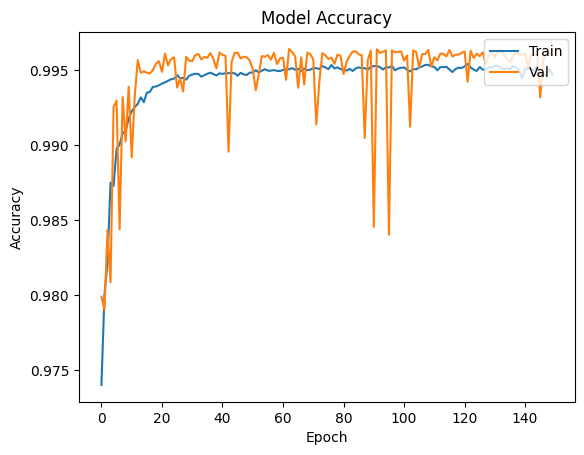

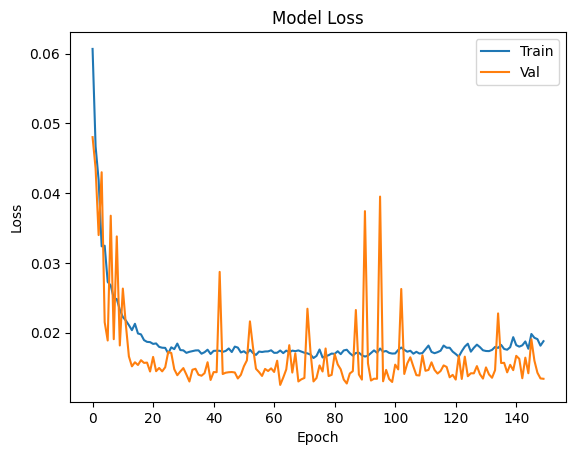

17675/17675 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step

 Classification Report:
                  precision    recall  f1-score   support

          Benign       1.00      1.00      1.00    454363
       DDoS-only       0.99      1.00      0.99     65701
      Fraud-only       0.99      0.98      0.99     34609
Fraud-under-DDoS       0.99      0.98      0.99     10903

        accuracy                           1.00    565576
       macro avg       0.99      0.99      0.99    565576
    weighted avg       1.00      1.00      1.00    565576



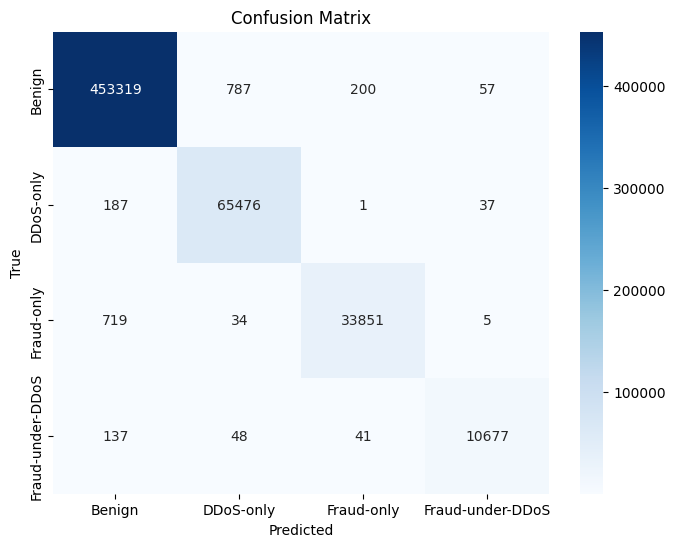

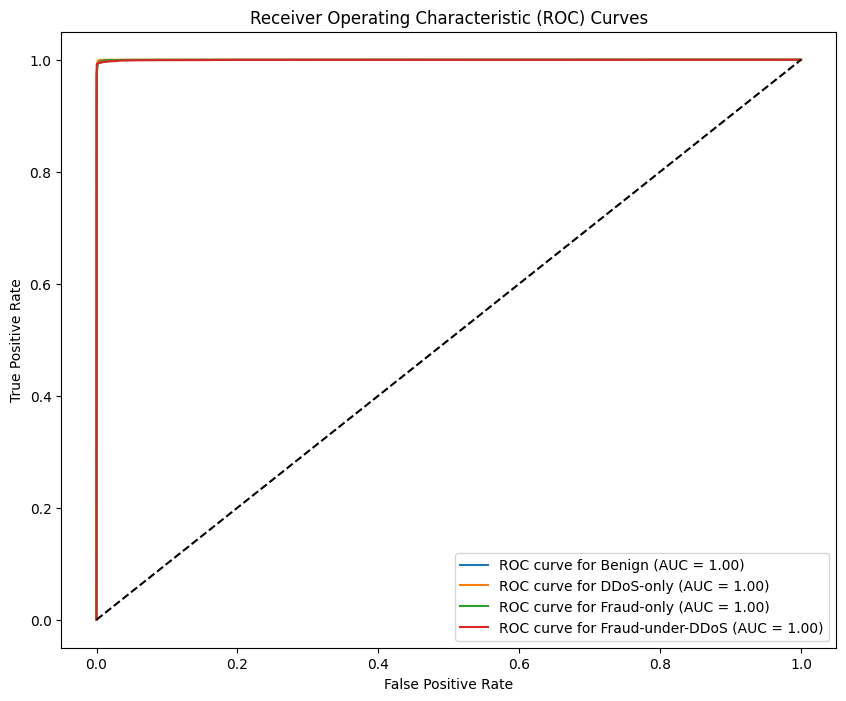


 AUC Score (OvR): 0.9998


In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
target_names = [str(c) for c in le.classes_]

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)


print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

plt.figure(figsize=(10, 8))
for i in range(len(target_names)):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f'ROC curve for {target_names[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()

try:
    auc_score = roc_auc_score(y_test, y_pred_probs, multi_class="ovr")
    print(f"\n AUC Score (OvR): {auc_score:.4f}")
except Exception as e:
    print(" Could not compute AUC:", e)


# Step 7: Implementation of Proposed CADE-GF

## Step 7 (a): Attacker Utility Function

In [ ]:
def attacker_utility(prob_fraud, threshold=0.5, cost_detected=1.0, reward_evade=5.0, cost_false_positive=0.5):
    if prob_fraud >= threshold:
        return -cost_detected * prob_fraud
    else:
        return reward_evade * (1 - prob_fraud) - cost_false_positive * prob_fraud

## Step 7 (b): Threshold Search Resolution Function

In [ ]:
def optimal_threshold(pred_probs, true_labels):
    thresholds = np.linspace(0.1, 0.9, 81)
    best_thresh = 0.5
    min_utility = float('inf')

    for t in thresholds:
        evasion_utilities = [
            attacker_utility(prob, threshold=t, cost_detected=2.0)
            for prob, true in zip(pred_probs, true_labels) if true != 0
        ]
        if evasion_utilities:
            avg_utility = np.mean(evasion_utilities)
            if avg_utility < min_utility:
                min_utility = avg_utility
                best_thresh = t
    return best_thresh

## Step 7 (c): Evasion Attack function

In [ ]:
def simulate_evasion(X, numeric_cols_indices, epsilon=0.1):
    X_evaded = X.copy()
    X_reshaped = X_evaded.reshape(X_evaded.shape[0], X_evaded.shape[2])
    noise = np.random.normal(0, epsilon, size=(X_reshaped.shape[0], len(numeric_cols_indices)))
    X_reshaped[:, numeric_cols_indices] += noise
    X_evaded = X_reshaped.reshape(X_evaded.shape)
    return X_evaded

## Step 8: Evalaution of CADE-GF
### Print Evalaution Metrics (AUC) Before/After

In [ ]:
feature_names = numeric_cols
continuous_traffic_features = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Bwd IAT Total',
    'Bwd IAT Mean', 'Bwd IAT Std', 'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Down/Up Ratio', 'Average Packet Size', 'Avg Fwd Segment Size',
    'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Fwd Avg Bytes/Bulk',
    'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
    'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets',
    'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd',
    'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max',
    'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
]
continuous_features_to_perturb = [f for f in continuous_traffic_features if f in feature_names]
continuous_feature_indices = [feature_names.index(f) for f in continuous_features_to_perturb if f in feature_names]
pred_probs = model.predict(X_test)
fraud_probs = pred_probs[:, 1]
y_true = np.argmax(y_test, axis=1)
opt_thresh = optimal_threshold(fraud_probs, y_true)
print(f"Optimal threshold: {opt_thresh:.3f}")
y_clean = (fraud_probs >= opt_thresh).astype(int)
X_evaded = simulate_evasion(X_test, continuous_feature_indices, epsilon=0.1)
fraud_probs_evaded = model.predict(X_evaded)[:, 1]
y_evaded = (fraud_probs_evaded >= opt_thresh).astype(int)
try:
    auc_clean = roc_auc_score(y_test, model.predict(X_test), multi_class='ovr')
    auc_evade = roc_auc_score(y_test, model.predict(X_evaded), multi_class='ovr')
    print(f"AUC (clean): {auc_clean:.4f}")
    print(f"AUC (evaded): {auc_evade:.4f}")
    print(f"AUC degradation: {auc_clean - auc_evade:.4f}")
    evasion_success = np.mean((y_clean == 1) & (y_evaded == 0))
    print(f"Evasion success rate: {evasion_success:.4f}")
except Exception as e:
    print(f"Evaluation error: {e}")

17675/17675 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step
Optimal threshold: 0.100
17675/17675 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step
17675/17675 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step
17675/17675 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step
AUC (clean): 0.9998
AUC (evaded): 0.9527
AUC degradation: 0.0471
Evasion success rate: 0.0243
